# Dynamic Query Analysis

The purpose of this analysis is to investigate the use of the first hit in a track to initialise the dynamic queries. There is a possibility that this approach may miss displaced hits, reducing the efficiency of the tagger.

## First hit initialisation

The first step is to investigate whether we do actually have an issue in using the first hit to initialise the dynamic queries. To do this, we wish to find the fraction of truth particles without a track that are classified as a first hit.

In [33]:
import h5py

# test_path = "/share/rcif2/mmangat/logs/TRK-v8-3l-fast-fix-vec_20260316-T104827/ckpts/epoch=020-val_loss=1.48183_test_eval.h5"
# test_path = "/Users/mungomangat/Documents/PhD/logs/TRK-v8-3l-fast-fix-vec_20260316-T104827/ckpts/epoch=020-val_loss=1.48183_test_eval.h5"  # First hit
test_path = "/Users/mungomangat/Documents/PhD/logs/TRK-v8-3l-fast-fix-vec_20260428-T172805/ckpts/epoch=004-val_loss=0.58669_test_eval.h5"  # Last hit
hit_filter_path = "/Users/mungomangat/Documents/PhD/epoch=022-val_loss=0.03377_test_eval.h5"


def print_tree(name, obj):
    indent = "  " * name.count("/")
    if isinstance(obj, h5py.Group):
        print(f"{indent}[{name}]")
    elif isinstance(obj, h5py.Dataset):
        print(f"{indent}{name}  shape={obj.shape} dtype={obj.dtype}")


with h5py.File(test_path, "r") as f:
    print("/")
    f["29800"].visititems(print_tree)

/
[outputs]
  [outputs/encoder]
    [outputs/encoder/query_init]
      outputs/encoder/query_init/hit_logits  shape=(1, 9370, 1) dtype=float16
  [outputs/final]
    [outputs/final/track_hit_valid]
      outputs/final/track_hit_valid/track_hit_logit  shape=(1, 2200, 9370) dtype=float16
    [outputs/final/track_iou]
      outputs/final/track_iou/query_iou_logit  shape=(1, 2200) dtype=float16
    [outputs/final/track_valid]
      outputs/final/track_valid/track_class_prob  shape=(1, 2200, 2) dtype=float16
      outputs/final/track_valid/track_logit  shape=(1, 2200) dtype=float16
[preds]
  [preds/encoder]
    [preds/encoder/query_init]
      preds/encoder/query_init/hit_is_first  shape=(1, 9370) dtype=bool
      preds/encoder/query_init/hit_is_first_prob  shape=(1, 9370) dtype=float16
  [preds/final]
    [preds/final/track_hit_valid]
      preds/final/track_hit_valid/track_hit_valid  shape=(1, 2200, 9370) dtype=bool
      preds/final/track_hit_valid/track_hit_valid_prob  shape=(1, 2200, 93

In [35]:
import numpy as np
import matplotlib.pyplot as plt

with h5py.File(test_path, "r") as f, h5py.File(hit_filter_path, "r") as r:
    all_pred = []
    all_true = []
    all_hits = []
    for event in f.keys():
        event_f = f[str(event)]
        event_r = r[str(event)]
        valid_hits_true = event_f["targets/hit_valid"][0]
        first_hits_true = event_f["targets/hit_is_first"][0] & valid_hits_true
        hit_in_track = event_f["outputs/final/track_hit_valid/track_hit_logit"][0] > 0
        first_hits_pred = event_f["preds/encoder/query_init/hit_is_first"][0] & valid_hits_true
        hit_r = event_r["inputs/hit_r"][0]

        all_pred.extend(hit_r[first_hits_pred])
        all_true.extend(hit_r[first_hits_true])
        all_hits.extend(hit_r)

In [36]:
total_hits = 9370 * 100
bins = np.linspace(0.2, 1.6, 8)

ratio_per_bin = []
all_pred = np.array(all_pred)
all_true = np.array(all_true)
for i in range(len(bins) - 1):
    bin_bottom = bins[i]
    bin_top = bins[i + 1]
    pred_in_bin = np.where((all_pred >= bin_bottom) & (all_pred < bin_top))
    true_in_bin = np.where((all_true >= bin_bottom) & (all_true < bin_top))
    if len(pred_in_bin[0]) == 0:
        ratio = 0
        ratio_per_bin.append(ratio)
        continue
    ratio = len(true_in_bin[0]) / len(pred_in_bin[0])
    ratio_per_bin.append(ratio)

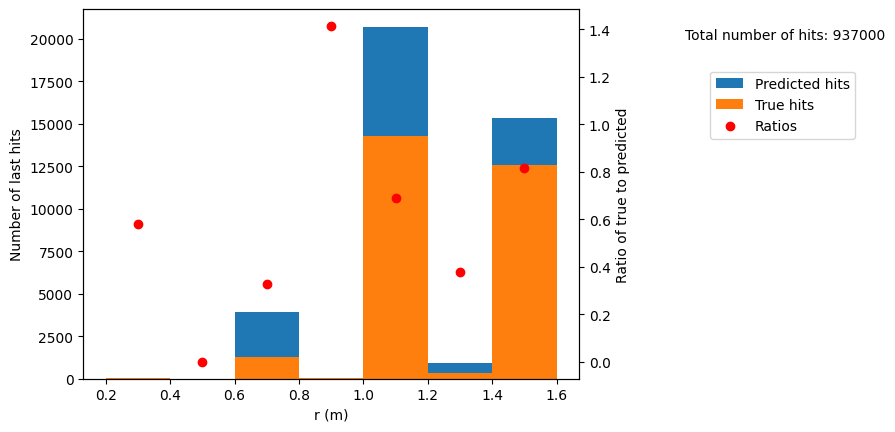

In [37]:
fig, ax = plt.subplots()
ax.hist(all_pred, bins=bins, label="Predicted hits")
ax.hist(all_true, bins=bins, label="True hits")
ax.text(2, 20000, "Total number of hits: " + str(total_hits))
ax.set_xlabel("r (m)")
ax.set_ylabel("Number of last hits")

ax2 = ax.twinx()
ax2.scatter(bins[:-1] + 0.1, ratio_per_bin, c="red", label="Ratios")
ax2.set_ylabel("Ratio of true to predicted")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(lines1 + lines2, labels1 + labels2, bbox_to_anchor=(1.25, 0.85))

In [38]:
displaced = 0.4

import numpy as np
import pandas as pd

first_hit_path = "/Users/mungomangat/Documents/PhD/logs/TRK-v8-3l-fast-fix-vec_20260316-T104827/ckpts/epoch=020-val_loss=1.48183_test_eval.h5"
displaced_tracks_df = pd.DataFrame(columns=["tracks", "event_id"])

with h5py.File(first_hit_path, "r") as f, h5py.File(hit_filter_path, "r") as r:
    for event in f.keys():
        event_f = f[str(event)]
        event_r = r[str(event)]
        hit_r = event_r["inputs/hit_r"][0]
        valid_hits_true = event_f["targets/hit_valid"][0]
        first_hits_true = event_f["targets/hit_is_first"][0] & valid_hits_true
        truth_matrix = event_f["targets/particle_hit_valid"][0]
        displaced_hits = hit_r > displaced
        displaced_first_hits = first_hits_true & displaced_hits
        displaced_first_hits_mask = np.tile(displaced_first_hits, (truth_matrix.shape[0], 1))
        displaced_tracks = np.any(displaced_first_hits_mask & truth_matrix, axis=1)

        displaced_tracks_temp_df = pd.DataFrame(displaced_tracks, columns=["tracks"])
        displaced_tracks_temp_df["event_id"] = event
        displaced_tracks_df = pd.concat([displaced_tracks_temp_df, displaced_tracks_df], ignore_index=True)

## Track evaluation

Offline track evaluation on the test HDF5 using the standard TrackML matching protocol (hit-overlap-based, independent of the Hungarian matching used during training).

## Efficiency split: displaced vs non-displaced particles

In [39]:
import sys

sys.path.insert(0, "src/hepattn/experiments/trackml/eval")
from track_evaluate import load_events

tracks, parts = load_events(
    fname=test_path,
    eta_cut=2.5,
    pt_cut=1.0,
    particle_targets=["pt", "eta", "phi"],
    regression=False,
)

rec = parts[parts.reconstructable]
trk_rec = tracks[tracks.reconstructable]
fakes = (~trk_rec.eff_dm) & (~trk_rec.duplicate)

print(f"Events: 100   |   Tracks: {len(tracks):,}   |   Particles: {len(parts):,}")
print(f"Reconstructable particles: {len(rec):,}")
print()
print("=== Efficiency (pT > 1 GeV, |eta| < 2.5) ===")
print(f"  Double Majority (DM):  {rec.eff_dm.mean():.3%}")
print(f"  Perfect:               {rec.eff_perfect.mean():.3%}")
print(f"  LHC (precision>0.75):  {rec.eff_lhc.mean():.3%}")
print()
print("=== Fake / duplicate rates (reconstructable tracks) ===")
print(f"  Fake rate:      {fakes.mean():.3%}")
print(f"  Duplicate rate: {trk_rec.duplicate.mean():.3%}")

parts_indexed = parts.copy()
parts_indexed["particle_idx"] = parts_indexed.groupby("event_id").cumcount()

displaced_indexed = displaced_tracks_df.copy()
displaced_indexed["particle_idx"] = displaced_indexed.groupby("event_id").cumcount()

merged = parts_indexed.merge(
    displaced_indexed.rename(columns={"tracks": "is_displaced"})[["event_id", "particle_idx", "is_displaced"]],
    on=["event_id", "particle_idx"],
)

rec = merged[merged["reconstructable"].to_numpy(dtype=bool)]
# .to_numpy(dtype=bool) converts Python bool objects → numpy bool_ so ~ works correctly
is_displaced_arr = rec["is_displaced"].to_numpy(dtype=bool)
disp = rec[is_displaced_arr]
non_disp = rec[~is_displaced_arr]

print()
print(f"=== Efficiency split by displaced (first hit r > {displaced}m) ===")
print(f"  Reconstructable particles: {len(rec):,}")
print(f"  Displaced:     {len(disp):,}  ({len(disp) / len(rec):.1%})")
print(f"  Non-displaced: {len(non_disp):,}  ({len(non_disp) / len(rec):.1%})")
print()
print("  DM Efficiency:")
print(f"    Displaced:     {disp.eff_dm.mean():.3%}")
print(f"    Non-displaced: {non_disp.eff_dm.mean():.3%}")
print()
print("  Perfect Efficiency:")
print(f"    Displaced:     {disp.eff_perfect.mean():.3%}")
print(f"    Non-displaced: {non_disp.eff_perfect.mean():.3%}")

Events: 100   |   Tracks: 177,310   |   Particles: 220,000
Reconstructable particles: 76,519

=== Efficiency (pT > 1 GeV, |eta| < 2.5) ===
  Double Majority (DM):  96.789%
  Perfect:               88.534%
  LHC (precision>0.75):  94.433%

=== Fake / duplicate rates (reconstructable tracks) ===
  Fake rate:      5.023%
  Duplicate rate: 0.184%

=== Efficiency split by displaced (first hit r > 0.4m) ===
  Reconstructable particles: 76,519
  Displaced:     2,045  (2.7%)
  Non-displaced: 74,474  (97.3%)

  DM Efficiency:
    Displaced:     78.973%
    Non-displaced: 97.278%

  Perfect Efficiency:
    Displaced:     52.323%
    Non-displaced: 89.528%
